# Évaluation du modèle de détection de langues `LanguageIdentification`


Ce notebook évalue les performances du modèle de détection de langues.
Le modèle utilise FastText pour identifier la langue d'un texte donné.


In [1]:

import pandas as pd

# Load dataset used for evaluation
df = pd.DataFrame([{'Text': 'Je dois rejoindre mes amis de Bordeaux à Paris. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9866545796394348}, {'Text': 'Nous partons pour un voyage en train ce matin. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9931715130805969}, {'Text': 'Le bus pour Lyon arrive dans dix minutes. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9902641177177429}, {'Text': "J'ai réservé un taxi pour aller à l'aéroport. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 1.0000287294387817}, {'Text': 'Mon vol pour Marseille est prévu à 18 heures. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9985552430152893}, {'Text': "Peux-tu m'indiquer le chemin pour aller à la gare ? 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9991897940635681}, {'Text': 'Je prends la ligne 1 du métro pour aller au travail. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9990473389625549}, {'Text': 'Nous avons loué une voiture pour explorer la région. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9996637105941772}, {'Text': "Le TGV est toujours à l'heure aujourd'hui. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9987415671348572}, {'Text': "J'ai oublié mon billet de train à la maison. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9993976950645447}, {'Text': 'Mon itinéraire passe par plusieurs villes pittoresques. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9764200448989868}, {'Text': 'Nous devons acheter nos tickets de tramway. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.7698220610618591}, {'Text': 'Le bateau partira du port à 14 heures précises. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9842197895050049}, {'Text': 'Je vais prendre un BlaBlaCar pour économiser sur le trajet. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9929348826408386}, {'Text': "Le trafic est dense sur l'autoroute A7 ce matin. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.865836501121521}, {'Text': 'Peux-tu vérifier le numéro de quai pour notre train ? 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9984741806983948}, {'Text': "Nous ferons une escale à Nice avant d'arriver à Cannes. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9992603659629822}, {'Text': 'Le covoiturage est une excellente option pour voyager. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9789534211158752}, {'Text': 'Il y a une grève des transports en commun demain. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9892389178276062}, {'Text': "Je marche jusqu'à la station de bus la plus proche. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9783914089202881}, {'Text': 'Mon train part de la voie 4 dans cinq minutes. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.980815052986145}, {'Text': 'Nous devons trouver un hôtel près de la gare. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9970161318778992}, {'Text': "J'ai pris un abonnement mensuel pour le TER. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9982471466064453}, {'Text': 'La SNCF annonce un retard pour notre train. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9415759444236755}, {'Text': 'Peux-tu vérifier si Uber est disponible ici ? 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9928981065750122}, {'Text': 'Nous partons tôt demain pour éviter les embouteillages. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.99875408411026}, {'Text': "Le billet aller-retour est moins cher que l'aller simple. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9026195406913757}, {'Text': "Le chauffeur de taxi m'a recommandé un itinéraire plus rapide. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9388572573661804}, {'Text': 'Je préfère voyager de nuit pour arriver tôt le matin. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.998465895652771}, {'Text': 'Les enfants adorent regarder le paysage depuis le train. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9708439707756042}, {'Text': 'Le prochain arrêt est à Montpellier, préparez vos bagages. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9797379374504089}, {'Text': 'Bonjour, comment allez-vous ? 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9861815571784973}, {'Text': 'Je suis ravi de vous rencontrer. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9974338412284851}, {'Text': "Quel temps fait-il aujourd'hui ? 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9993943572044373}, {'Text': "Pouvez-vous m'aider avec ce problème ? 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 1.0000309944152832}, {'Text': 'Je vais faire une promenade cet après-midi. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9942426085472107}, {'Text': 'Ce soir, nous allons regarder un film. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9067212343215942}, {'Text': 'Avez-vous déjà visité la Tour Eiffel ? 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9896371960639954}, {'Text': 'Mon plat préféré est la ratatouille. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9930246472358704}, {'Text': 'Les enfants adorent jouer dans le parc. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9971684813499451}, {'Text': "J'aime écouter de la musique classique. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9981756210327148}, {'Text': 'Le marché local est ouvert tous les dimanches. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9541800618171692}, {'Text': 'Mon train partira dans une heure. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9986476302146912}, {'Text': 'Cette recette est facile et rapide à préparer. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.997603714466095}, {'Text': 'Je prends mon café sans sucre. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9322726726531982}, {'Text': 'La fête commence à 19 heures. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9870201349258423}, {'Text': 'Le ciel est clair et le soleil brille. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9268951416015625}, {'Text': "Il est important de protéger l'environnement. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9569013118743896}, {'Text': 'Nous avons réservé une table pour deux. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 1.0000334978103638}, {'Text': 'Les montagnes sont magnifiques en hiver. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.992537796497345}, {'Text': 'Apprenez une nouvelle langue est enrichissant. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.990979015827179}, {'Text': "Je préfère voyager en train qu'en avion. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9995703101158142}, {'Text': 'Les enfants ont construit un château de sable. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9743768572807312}, {'Text': "Ce musée abrite des œuvres d'art célèbres. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9974521398544312}, {'Text': 'Il faut toujours se laver les mains avant de manger. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9826358556747437}, {'Text': 'Les fleurs dans le jardin sont en pleine floraison. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9985432028770447}, {'Text': 'Le concert aura lieu la semaine prochaine. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9604325890541077}, {'Text': 'La mer est calme et propice à la baignade. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9506934881210327}, {'Text': 'Il est interdit de fumer dans cet endroit. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9957456588745117}, {'Text': "J'adore lire des romans policiers. 🇫🇷", 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9823994636535645}, {'Text': 'Les élèves préparent un spectacle pour leurs parents. 🇫🇷', 'True Label': 'fr', 'Predicted Label': 'fr', 'Confidence': 0.9963011145591736}])
df_results = df


## Résultats des prédictions


Ce tableau montre les résultats des prédictions du modèle :
- **Text** : Le texte évalué.
- **True Label** : La langue réelle du texte.
- **Predicted Label** : La langue prédite par le modèle.
- **Confidence** : Le niveau de confiance de la prédiction (entre 0 et 1).


In [2]:

# Display full evaluation results
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_colwidth", None)  # Show full content in cells
df_results


,Text,True Label,Predicted Label,Confidence
0,Je dois rejoindre mes amis de Bordeaux à Paris. 🇫🇷,fr,fr,0.986655
1,Nous partons pour un voyage en train ce matin. 🇫🇷,fr,fr,0.993172
2,Le bus pour Lyon arrive dans dix minutes. 🇫🇷,fr,fr,0.990264
3,J'ai réservé un taxi pour aller à l'aéroport. 🇫🇷,fr,fr,1.000029
4,Mon vol pour Marseille est prévu à 18 heures. 🇫🇷,fr,fr,0.998555
5,Peux-tu m'indiquer le chemin pour aller à la gare ? 🇫🇷,fr,fr,0.999190
6,Je prends la ligne 1 du métro pour aller au travail. 🇫🇷,fr,fr,0.999047
7,Nous avons loué une voiture pour explorer la région. 🇫🇷,fr,fr,0.999664
8,Le TGV est toujours à l'heure aujourd'hui. 🇫🇷,fr,fr,0.998742
9,J'ai oublié mon billet de train à la maison. 🇫🇷,fr,fr,0.999398


## Distribution des scores de confiance


Ce graphique montre la distribution des scores de confiance pour toutes les prédictions valides :
- L'axe **x** représente les scores de confiance (de 0 à 1).
- L'axe **y** représente le nombre de prédictions ayant un score de confiance dans une plage donnée.
Un pic élevé près de 1 indique que le modèle est confiant dans ses prédictions.


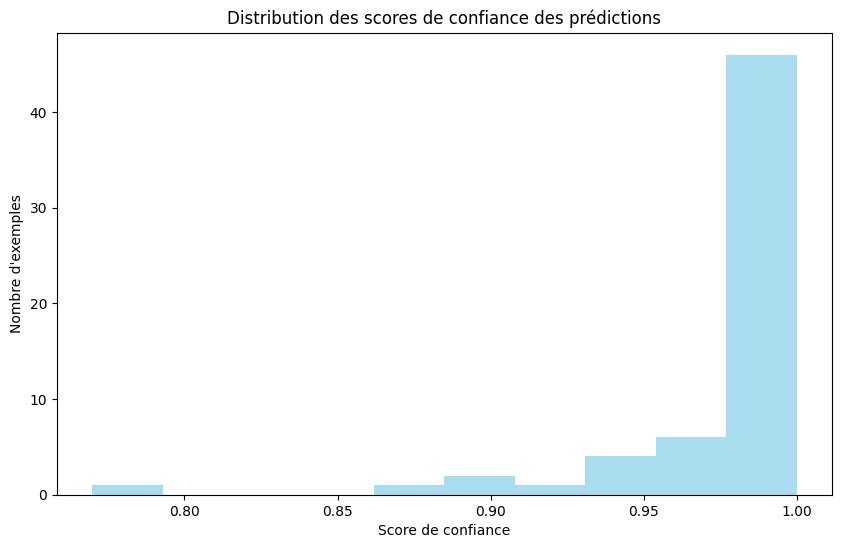

In [3]:

import matplotlib.pyplot as plt

# Filter valid confidences
confidences = df_results["Confidence"].dropna()

plt.figure(figsize=(10, 6))
plt.hist(confidences, bins=10, color='skyblue', alpha=0.7)
plt.title("Distribution des scores de confiance des prédictions")
plt.xlabel("Score de confiance")
plt.ylabel("Nombre d'exemples")
plt.show()


## Courbe cumulative des scores de confiance


Ce graphique montre la proportion cumulée des prédictions atteignant un certain seuil de confiance :
- L'axe **x** représente les scores de confiance (de 0 à 1).
- L'axe **y** représente la proportion cumulative des prédictions valides.
Une montée rapide dans la courbe indique que la majorité des prédictions ont des scores élevés.


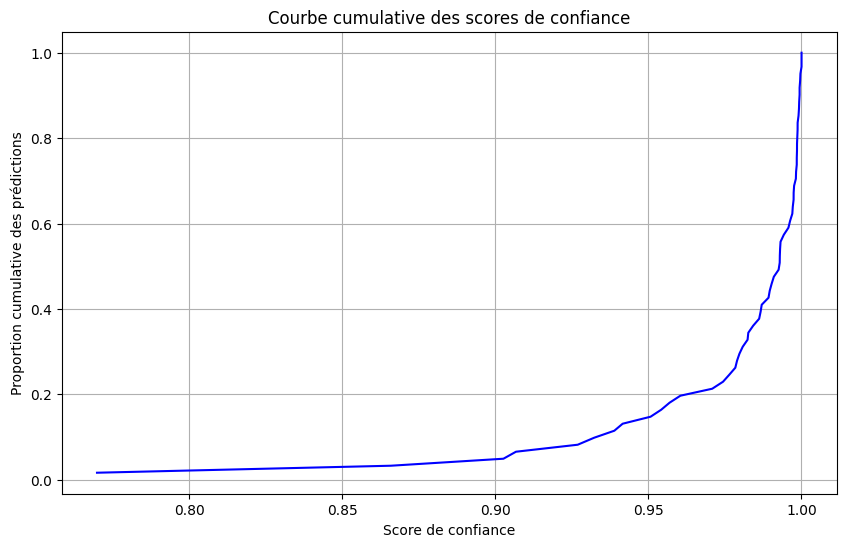

In [4]:

# Sort and calculate cumulative confidence scores
sorted_confidences = confidences.sort_values()
cumulative = sorted_confidences.rank(pct=True).values

plt.figure(figsize=(10, 6))
plt.plot(sorted_confidences, cumulative, color="blue")
plt.title("Courbe cumulative des scores de confiance")
plt.xlabel("Score de confiance")
plt.ylabel("Proportion cumulative des prédictions")
plt.grid()
plt.show()


## Distribution des longueurs de texte


Ce graphique montre comment la longueur des textes évalués est répartie :
- L'axe **x** représente la longueur des textes (en caractères).
- L'axe **y** représente le nombre de textes de chaque longueur.
Cela permet d'identifier si la performance varie en fonction de la longueur des phrases.


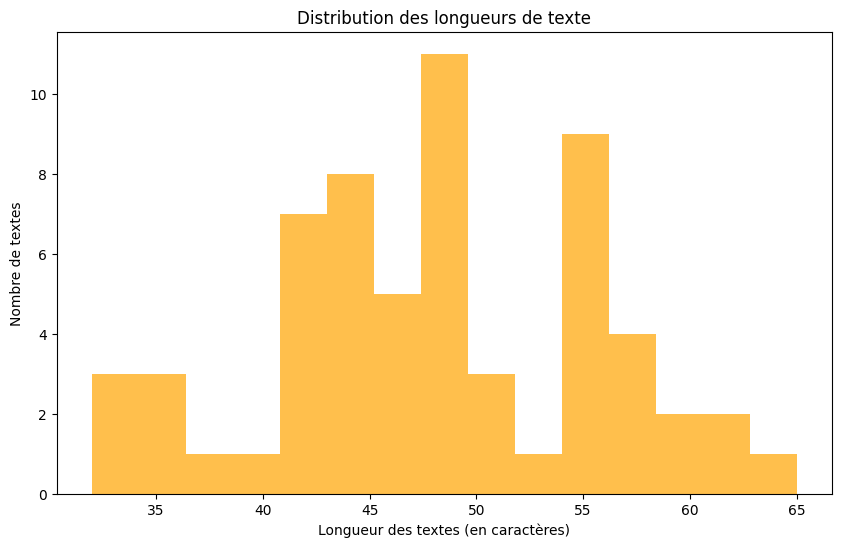

In [5]:

# Calculate text lengths
df_results["Text Length"] = df_results["Text"].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(df_results["Text Length"], bins=15, color='orange', alpha=0.7)
plt.title("Distribution des longueurs de texte")
plt.xlabel("Longueur des textes (en caractères)")
plt.ylabel("Nombre de textes")
plt.show()


## Performance en fonction du seuil de confiance


Ce graphique montre comment la précision évolue en fonction du seuil de confiance :
- L'axe **x** représente les seuils de confiance.
- L'axe **y** représente la précision.
Cela aide à déterminer un seuil optimal pour garantir des prédictions fiables.


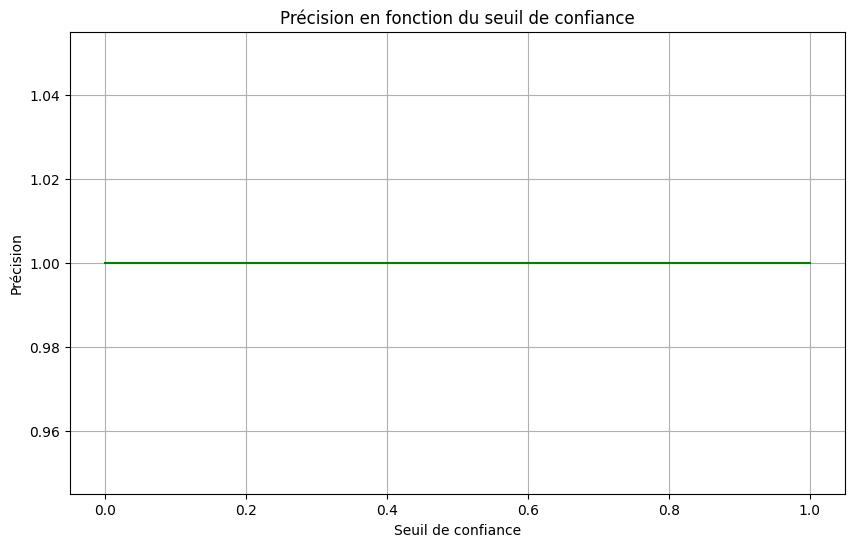

In [6]:

import numpy as np

thresholds = np.linspace(0, 1, 50)
precisions = []

for threshold in thresholds:
    filtered = df_results[df_results["Confidence"] >= threshold]
    if len(filtered) > 0:
        precision = (filtered["True Label"] == filtered["Predicted Label"]).mean()
        precisions.append(precision)
    else:
        precisions.append(0)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, color="green")
plt.title("Précision en fonction du seuil de confiance")
plt.xlabel("Seuil de confiance")
plt.ylabel("Précision")
plt.grid()
plt.show()
